# Comparing Neural Networks and Polynomial Regression for Function Approximation

# Imports


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

import torch
import torch.nn as nn
import torch.optim as optim

import random
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)


# Dataset/Functions

In [2]:
def f_smooth(x):
    return x**2

def f_oscillatory(x):
    return np.sin(5 * x)

def f_piecewise(x):
    return np.abs(x)

In [3]:
x = np.linspace(-2, 2, 200)
#y = f_smooth(x)
#y = f_oscillatory(x)
y = f_piecewise(x)

In [4]:

train_idx = np.random.choice(len(x), size=150, replace=False)
test_idx = np.setdiff1d(np.arange(len(x)), train_idx)

x_train, y_train = x[train_idx], y[train_idx]
x_test, y_test = x[test_idx], y[test_idx]

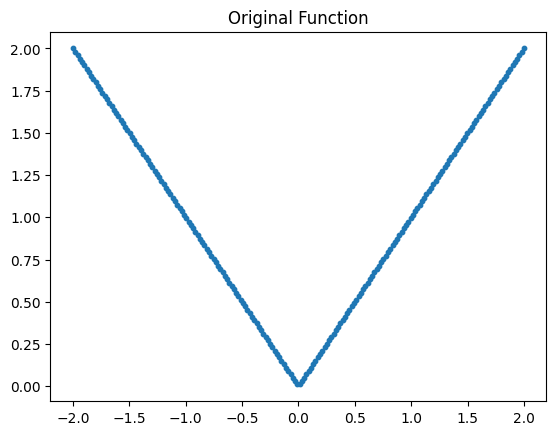

In [5]:
plt.scatter(x, y, s=10)
plt.title("Original Function")
plt.show()

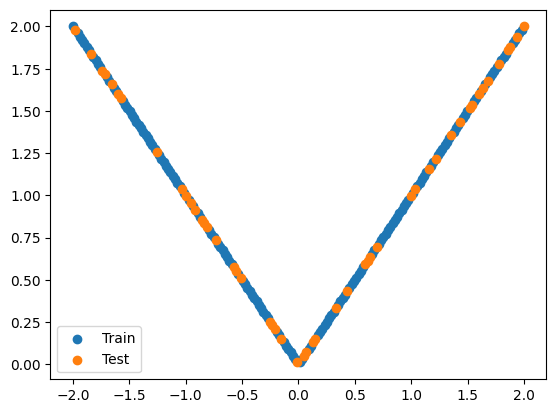

In [6]:
plt.scatter(x_train, y_train, label="Train")
plt.scatter(x_test, y_test, label="Test")
plt.legend()
plt.show()

# Polynomial Regression

In [7]:
def run_polynomial_regression(degree):
    X_train = x_train.reshape(-1, 1)
    X_test = x_test.reshape(-1, 1)

    poly = PolynomialFeatures(degree=degree)
    X_train_poly = poly.fit_transform(X_train)
    X_test_poly = poly.transform(X_test)

    model = LinearRegression()
    model.fit(X_train_poly, y_train)

    y_pred = model.predict(X_test_poly)
    mse = mean_squared_error(y_test, y_pred)

    return y_pred, mse

In [8]:
y_pred, mse = run_polynomial_regression(11)
print("Polynomial Mean Squared Error:", mse)

Polynomial Mean Squared Error: 0.0006771096489713956


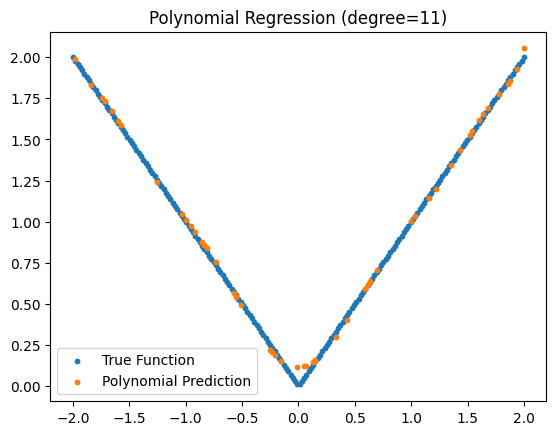

In [9]:
plt.scatter(x, y, label="True Function", s=10)
plt.scatter(x_test, y_pred, label="Polynomial Prediction", s=10)

plt.legend()
plt.title(f"Polynomial Regression (degree=11)")
plt.show()

# Neural Network Model


In [10]:
x_train_t = torch.tensor(x_train, dtype=torch.float32).view(-1, 1)
y_train_t = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)

x_test_t = torch.tensor(x_test, dtype=torch.float32).view(-1, 1)
y_test_t = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)



In [11]:
import torch.nn as nn

class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_sizes, activation):
        super().__init__()

        layers = []
        prev_size = input_size

        for h in hidden_sizes:
            layers.append(nn.Linear(prev_size, h))
            layers.append(activation())
            prev_size = h

        layers.append(nn.Linear(prev_size, 1))

        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

In [12]:
import torch.optim as optim
def train_model(model, x_train, y_train, epochs=500, lr=0.01):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    loss_fn = nn.MSELoss()

    for epoch in range(epochs):
        optimizer.zero_grad()
        pred = model(x_train)
        loss = loss_fn(pred, y_train)
        loss.backward()
        optimizer.step()

    return model

In [13]:
def evaluate_model(model, x_test, y_test):
    loss_fn = nn.MSELoss()
    with torch.no_grad():
        pred = model(x_test)
        mse = loss_fn(pred, y_test)
    return pred, mse.item()

In [14]:
model = NeuralNet(1, [10], nn.ReLU)

model = train_model(model, x_train_t, y_train_t)

y_pred_nn, mse_nn = evaluate_model(model, x_test_t, y_test_t)

print("NN MSE:", mse_nn)

NN MSE: 8.105712186079472e-05


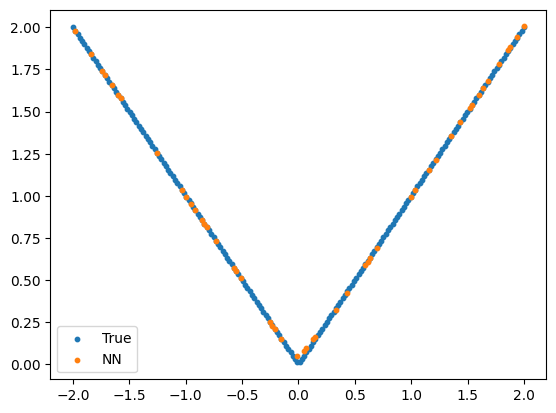

In [15]:
plt.scatter(x, y, label="True", s=10)
plt.scatter(x_test, y_pred_nn.numpy(), label="NN", s=10)

plt.legend()
plt.show()

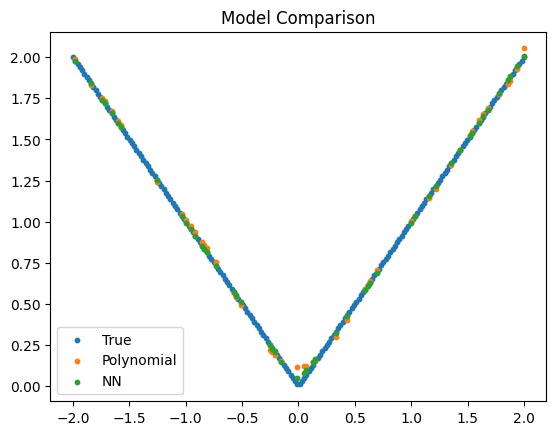

In [16]:
plt.scatter(x, y, label="True", s=10)
plt.scatter(x_test, y_pred, label="Polynomial", s=10)
plt.scatter(x_test, y_pred_nn.numpy(), label="NN", s=10)

plt.legend()
plt.title("Model Comparison")
plt.show()

# Experiments


In [17]:
degrees = [1, 2, 3, 5, 10, 20, 40, 50]

results = []

for d in degrees:
    y_pred, mse = run_polynomial_regression(d)
    results.append((d, mse))
    print(f"Degree {d}: MSE = {mse}")

Degree 1: MSE = 0.3866342696311292
Degree 2: MSE = 0.023461042018307687
Degree 3: MSE = 0.023542439413526312
Degree 5: MSE = 0.006533651194647538
Degree 10: MSE = 0.0006750708942977393
Degree 20: MSE = 0.00016908504784713112
Degree 40: MSE = 0.034667660767427666
Degree 50: MSE = 4.192454055096887


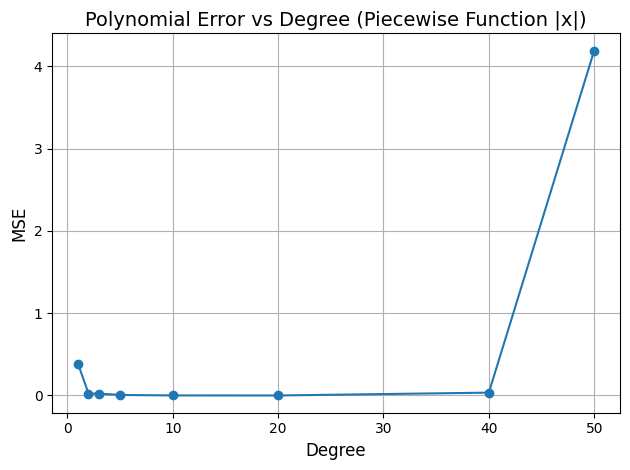

In [18]:
degrees_list = [r[0] for r in results]
mse_list = [r[1] for r in results]

plt.plot(degrees_list, mse_list, marker='o')
plt.xlabel("Degree", fontsize=12)
plt.ylabel("MSE", fontsize=12)
plt.title("Polynomial Error vs Degree (Piecewise Function |x|)", fontsize=14)
plt.grid(True)
plt.tight_layout()
plt.show()

In [19]:
architectures = [
    [5],
    [10],
    [100],
    [10, 10],
    [100, 100],
    [10, 10, 10],
    [100, 100, 100]
]

labels = []
mse_values = []

for arch in architectures:
    model = NeuralNet(1, arch, nn.ReLU)
    model = train_model(model, x_train_t, y_train_t)
    _, mse = evaluate_model(model, x_test_t, y_test_t)

    labels.append(str(arch))
    mse_values.append(mse)

    print(f"Architecture {arch}: MSE = {mse}")

Architecture [5]: MSE = 6.431394285755232e-05
Architecture [10]: MSE = 0.0005772454896941781
Architecture [100]: MSE = 0.0002163393364753574
Architecture [10, 10]: MSE = 0.00015946125495247543
Architecture [100, 100]: MSE = 6.701141956000356e-06
Architecture [10, 10, 10]: MSE = 8.941268606577069e-05
Architecture [100, 100, 100]: MSE = 6.030375971022295e-06


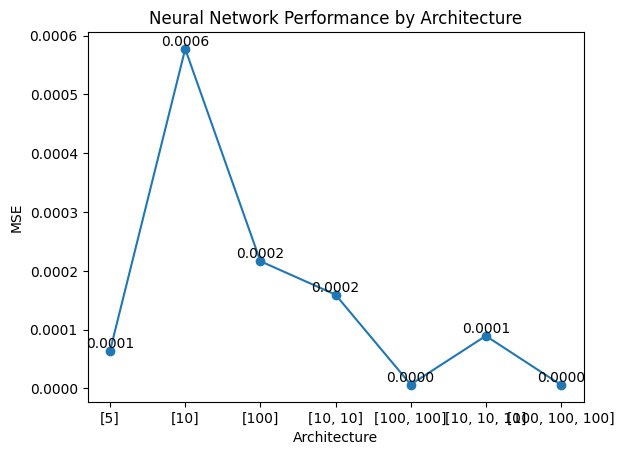

In [20]:
plt.figure()

plt.plot(labels, mse_values, marker='o')

for i, mse in enumerate(mse_values):
    plt.text(i, mse, f"{mse:.4f}", ha='center', va='bottom')

plt.xlabel("Architecture")
plt.ylabel("MSE")
plt.title("Neural Network Performance by Architecture")

plt.show()

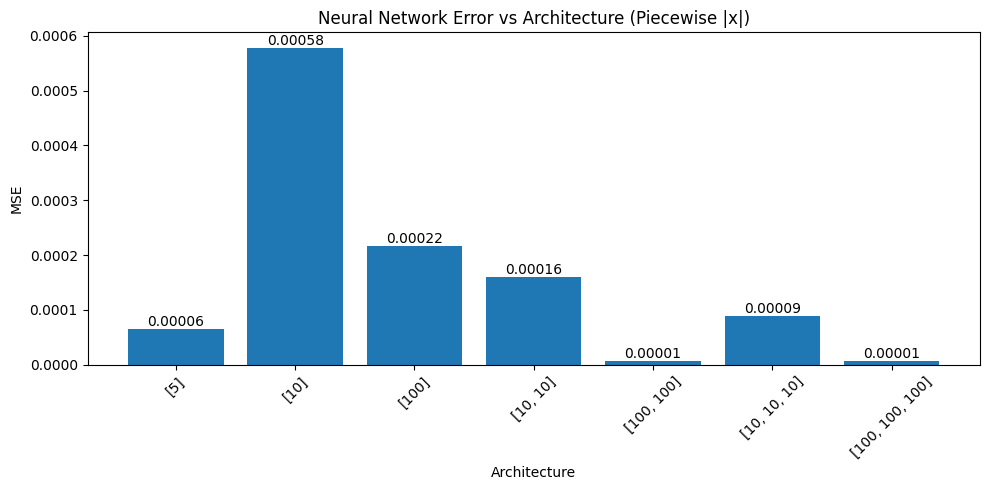

In [21]:
plt.figure(figsize=(10, 5))

bars = plt.bar(range(len(labels)), mse_values)

plt.xticks(range(len(labels)), labels, rotation=45)

for bar, mse in zip(bars, mse_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(),
             f"{mse:.5f}", ha='center', va='bottom')

plt.xlabel("Architecture")
plt.ylabel("MSE")
plt.title("Neural Network Error vs Architecture (Piecewise |x|)")

plt.tight_layout()
plt.show()

In [22]:
activations = [nn.ReLU, nn.Tanh, nn.Sigmoid]

results = []

for act in activations:
    model = NeuralNet(1, [10, 10], act)
    model = train_model(model, x_train_t, y_train_t)

    _, mse = evaluate_model(model, x_test_t, y_test_t)

    results.append((act.__name__, mse))
    print(f"{act.__name__}: MSE = {mse}")

ReLU: MSE = 0.00020888494327664375
Tanh: MSE = 0.0017721779877319932
Sigmoid: MSE = 0.005332148168236017


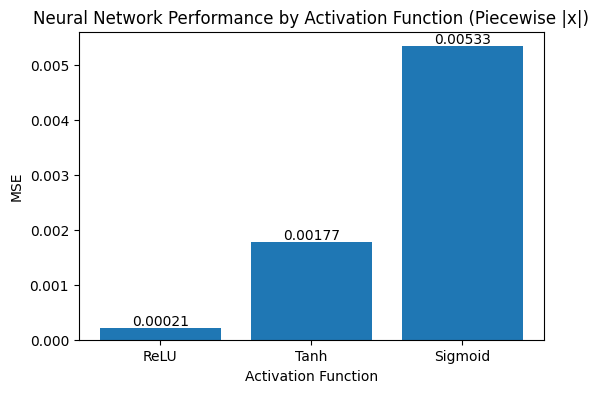

In [23]:
labels = [r[0] for r in results]
mse_values = [r[1] for r in results]

plt.figure(figsize=(6,4))

plt.bar(labels, mse_values)

for i, mse in enumerate(mse_values):
    plt.text(i, mse, f"{mse:.5f}", ha='center', va='bottom')

plt.xlabel("Activation Function")
plt.ylabel("MSE")
plt.title("Neural Network Performance by Activation Function (Piecewise |x|)")

plt.show()

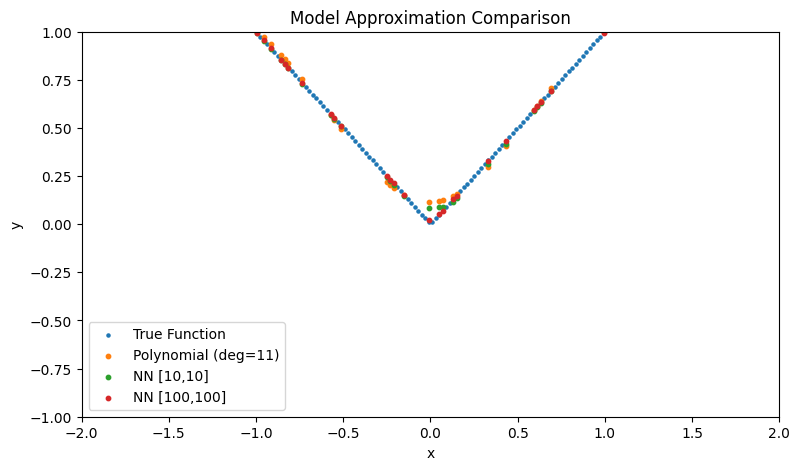

Polynomial MSE: 0.0006771096489713956
NN [10,10] MSE: 0.0001676557822073875
NN [100,100] MSE: 4.315430268596792e-06


In [24]:



y_pred_poly, _ = run_polynomial_regression(11)


model_small = NeuralNet(1, [10, 10], nn.ReLU)
model_small = train_model(model_small, x_train_t, y_train_t)

with torch.no_grad():
    y_pred_nn_small = model_small(x_test_t).detach().numpy()


model_large = NeuralNet(1, [100, 100], nn.ReLU)
model_large = train_model(model_large, x_train_t, y_train_t)

with torch.no_grad():
    y_pred_nn_large = model_large(x_test_t).detach().numpy()


plt.figure(figsize=(9,5))

plt.scatter(x, y, label="True Function", s=5)
plt.scatter(x_test, y_pred_poly, label="Polynomial (deg=11)", s=10)
plt.scatter(x_test, y_pred_nn_small, label="NN [10,10]", s=10)
plt.scatter(x_test, y_pred_nn_large, label="NN [100,100]", s=10)

plt.xlabel("x")
plt.ylabel("y")
plt.title("Model Approximation Comparison")
plt.legend()

plt.xlim(-2, 2)
plt.ylim(-1, 1)

plt.show()

mse_poly = mean_squared_error(y_test, y_pred_poly)

mse_nn_small = mean_squared_error(y_test, y_pred_nn_small)

mse_nn_large = mean_squared_error(y_test, y_pred_nn_large)

print("Polynomial MSE:", mse_poly)
print("NN [10,10] MSE:", mse_nn_small)
print("NN [100,100] MSE:", mse_nn_large)